In [ ]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from flax import nnx


from probjax.nn.loss_fn.denoising import build_time_dependent_denoising_loss

from probjax.nn import MLP, GaussianFourierEmbedding
from probjax.nn.nets.diffusion_model import EDM, VE, VP


In [3]:
# MNIST data
from datasets import load_dataset
import numpy as np

dataset = load_dataset('mnist', keep_in_memory=True)

dataset.set_format(type='numpy', columns=['image'])


In [98]:
train_data = dataset["train"]   

def train_data_generator(batch_size=32):
    key = jax.random.key(0)
    while True:
        key,subkey = jax.random.split(key,2)
        idx = np.random.randint(0,len(train_data), size=batch_size)
        xs_batch = jnp.array(train_data[idx]["image"]/256, dtype=jnp.float32).reshape(batch_size, 28,28,1)
        xs_batch += jax.random.uniform(subkey, xs_batch.shape)/255
        yield xs_batch

datagenerator = train_data_generator()

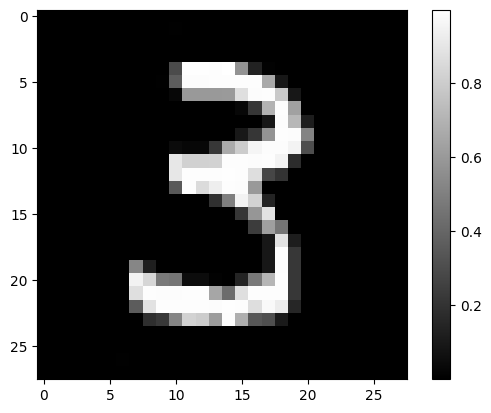

In [5]:
plt.imshow(next(datagenerator)[0], cmap="gray")
plt.colorbar()

In [6]:
from probjax.nn.nets.unets import UNet



In [19]:
d = 784
class BaseModel(nnx.Module, experimental_pytree=True):
    def __init__(self, d, rngs) -> None:
        self.time_embedding = GaussianFourierEmbedding(1,256, rngs=rngs, learnable=True)
        self.net = UNet(1, rngs=rngs, kernel_size=(4,4), kernel_size_resnet=(3,3), out_features=[32,64,128, 256, 512], context_features=256, use_bias=True, num_groups=4)
        self.last_layer = nnx.Conv(1,1, kernel_size=(1,1), rngs=rngs, kernel_init=nnx.initializers.zeros, use_bias=False)

    def __call__(self, t,x, *args, **kwargs):
        time_embed = self.time_embedding(t)
        out = self.net(x, context=time_embed)
        out = self.last_layer(out)

        return out

net = BaseModel(d, nnx.Rngs(1))
model = EDM(net, 1.)
params = nnx.state(model, nnx.Param)

In [20]:
model.c_skip(2.), model.c_out(2.)

(Array([0.2], dtype=float32, weak_type=True),
 Array([0.894], dtype=float32, weak_type=True))

In [21]:
def mean_fn(t, x):
    return x

def std_fn(t, x):
    return model.std_fn(t) 

denoiser_loss_fn = build_time_dependent_denoising_loss(model, mean_fn=mean_fn, std_fn=std_fn, weight_fn=model.weight_fn, reduction_fn=lambda x: x)

In [60]:
def loss_fn(params, x, rng):
    rng_times, rng_loss = jax.random.split(rng, 2)
    nnx.update(model, params)
    logt = jax.random.normal(rng_times, shape=(x.shape[0], 1,1,1)) * 1.2 - 1.2
    t = jnp.exp(logt) 

    eps = jax.random.normal(rng_loss, x.shape) * t 
    x_noise = x + eps 
    x_denoised = model(t, x_noise)
    weight = model.weight_fn(t)[...,None]
    l = jnp.mean(weight*(x - x_denoised)**2, axis=(-1,-2,-3))

    return jnp.mean(l)


In [61]:
loss_fn(params, next(datagenerator), jax.random.PRNGKey(0))

(32, 28, 28, 32)
(32, 14, 14, 64)
(32, 7, 7, 128)
(32, 4, 4, 256)
(32, 2, 2, 512)
(32, 2, 2, 512)
(32, 4, 4, 256)
(32, 8, 8, 128)
(32, 14, 14, 64)


Array(0.056, dtype=float32)

In [95]:

import optax



opt = optax.chain(optax.adaptive_grad_clip(10.), optax.ema(0.2),optax.adamw(5e-4))
opt_state = opt.init(params)
@jax.jit
def update(params, opt_state, x, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, x, rng)
    updates, opt_state = opt.update(grads, opt_state, params=params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

In [96]:
key = jax.random.key(2)

In [99]:

for i in range(100):
    l = 0.
    for j in range(2000): # Around one epoch
        key,key_data, key_loss = jax.random.split(key, 3)
        xs = next(datagenerator)
        params, opt_state, loss = update(params, opt_state, xs,key_loss)
        l += loss
    print(l/2000)


(32, 28, 28, 32)
(32, 14, 14, 64)
(32, 7, 7, 128)
(32, 4, 4, 256)
(32, 2, 2, 512)
(32, 2, 2, 512)
(32, 4, 4, 256)
(32, 8, 8, 128)
(32, 14, 14, 64)
0.05763638
0.05766922
0.05752441
0.057554808
0.057700057
0.057651818
0.057507563
0.057459403
0.057142455
0.057673935


KeyboardInterrupt: 

In [100]:
nnx.update(model, params)

In [126]:
from probjax.utils.odeint import odeint
from probjax.utils.sdeint import sdeint


def sample(rng, t_min=0.0001, t_max=80, rho=7, N = 1000):
    rng_init, rng_solve = jax.random.split(rng)
    eps = jax.random.normal(rng_init, (784,)) * t_max
    ts = (t_max**(1/rho) + jnp.linspace(0,1,N) * (t_min**(1/rho) - t_max**(1/rho)))**rho

    def drift(t, x):
        t = jnp.atleast_1d(t)
        x_ = x.reshape((28,28,1))
        f = model.drift(t,x_)
        g = model.diffusion(t, x_)
        score = model.score(t,x_)
        backward_f = (f -g**2*score).reshape(x.shape)
        return backward_f
    
    def diffusion(t, x):
        t = jnp.atleast_1d(t)
        x_ = x.reshape((28,28,1))
        g = model.diffusion(t, x_) * jnp.ones_like(x)
        return g.reshape(x.shape)

    return sdeint(rng_solve,drift,diffusion, eps,ts, noise_type="diagonal")[-1]


In [127]:
keys = jax.random.split(key, (100,))

In [128]:
xs = jax.vmap(sample)(keys)

(28, 28, 32)
(14, 14, 64)
(7, 7, 128)
(4, 4, 256)
(2, 2, 512)
(2, 2, 512)
(4, 4, 256)
(8, 8, 128)
(14, 14, 64)


In [129]:
xs.max(), xs.min()

(Array(1.137, dtype=float32), Array(-0.019, dtype=float32))

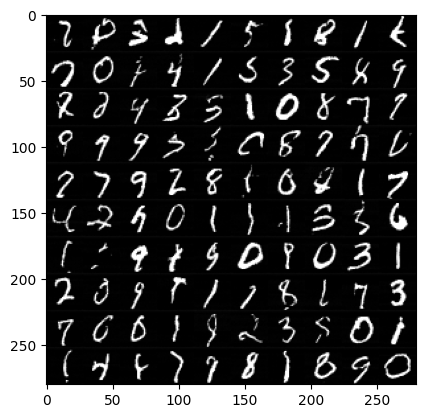

In [130]:
import matplotlib.pyplot as plt

img = xs.reshape(10, 10, 28, 28).transpose(0, 2, 1, 3).reshape(10*28, 10*28)
plt.imshow(img, cmap="gray", vmin=0, vmax=1.)